In [1]:
from lookup_historic import lookup_historical_rent

from matplotlib import pyplot as plt

In [7]:
test = lookup_historical_rent(12055, 69.98, 1916, "Niemetzstr%", 12)

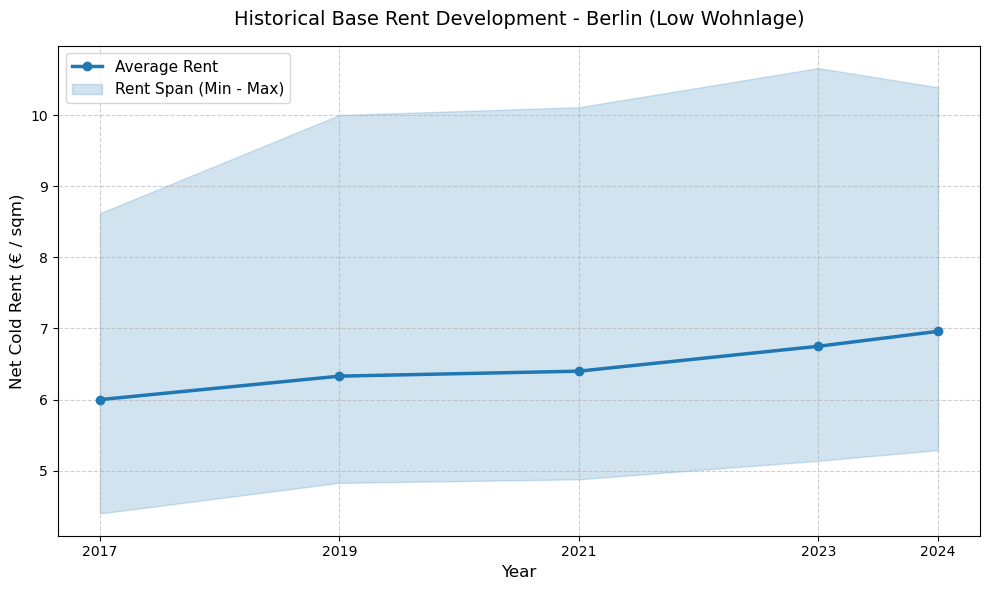

In [ ]:
import sqlite3
import argparse
import sys
import os

DB_PATH = 'db/miet_data.db'

# Mapping numeric API/DB values to the text categories in the rent grid
WOHNLAGE_MAPPING = {
    "1": "low",
    "2": "mid",
    "3": "good"
}

def get_zip_distribution(zip_code):
    """
    Analyzes the address database to find the % distribution of quality 
    levels within a specific ZIP code.
    """
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    
    cursor.execute('''
        SELECT wohnlage, COUNT(*) 
        FROM berlin_addresses 
        WHERE zip = ? 
        GROUP BY wohnlage
    ''', (str(zip_code),))
    
    rows = cursor.fetchall()
    conn.close()
    
    if not rows:
        return None

    total = sum(row[1] for row in rows)
    # Calculate weights (e.g., {'low': 0.2, 'mid': 0.7, 'good': 0.1})
    dist = {v: 0.0 for v in WOHNLAGE_MAPPING.values()}
    for val, count in rows:
        key = WOHNLAGE_MAPPING.get(str(val))
        if key:
            dist[key] = count / total
            
    return dist

def get_wohnlage_from_address(street, house_nr, zip_code):
    """Finds exact quality for a specific address."""
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    
    # Normalizing search for robustness
    clean_street = street.replace(" ", "").replace(".", "").replace("ß", "ss").lower()
    
    query = '''
        SELECT wohnlage, district 
        FROM berlin_addresses 
        WHERE LOWER(REPLACE(REPLACE(REPLACE(street, ' ', ''), '.', ''), 'ß', 'ss')) LIKE ?
          AND house_nr = ? 
          AND zip = ?
        LIMIT 1
    '''
    cursor.execute(query, (f"{clean_street}%", str(house_nr), str(zip_code)))
    result = cursor.fetchone()
    conn.close()

    if result:
        return WOHNLAGE_MAPPING.get(str(result[0]), "mid"), result[1]
    return None, None

def lookup_historical_rent(zip_code, size, building_year, street=None, house_nr=None):
    if not os.path.exists(DB_PATH):
        return {"error": "Database not found. Please run setup scripts first."}

    # 1. Determine Weights
    weights = {}
    is_weighted = False
    display_context = ""

    if street and house_nr:
        quality, district = get_wohnlage_from_address(street, house_nr, zip_code)
        if quality:
            weights = {quality: 1.0}
            display_context = f"Exact Address: {street} {house_nr} ({district})"
        else:
            return {"error": f"Address {street} {house_nr} not found in ZIP {zip_code}."}
    else:
        dist = get_zip_distribution(zip_code)
        if not dist:
            # Absolute fallback if ZIP has no address data at all
            weights = {"mid": 1.0}
            display_context = "Fallback (No ZIP data): 100% MID"
        else:
            weights = dist
            is_weighted = True
            parts = [f"{int(v*100)}% {k.upper()}" for k, v in dist.items() if v > 0]
            display_context = f"Weighted ZIP Average ({', '.join(parts)})"

    # 2. Fetch Catalogs
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute('SELECT id, version_year FROM mietspiegel_catalog WHERE ? BETWEEN zip_code_min AND zip_code_max ORDER BY version_year DESC', (zip_code,))
    catalogs = cursor.fetchall()

    history = []
    for cat_id, year in catalogs:
        # Fetch all possible qualities for this specific year/size/building_year
        cursor.execute('''
            SELECT wohnlage, rent_sqm_min, rent_sqm_avg, rent_sqm_max
            FROM mietspiegel
            WHERE catalog_id = ? 
              AND ? BETWEEN buildingyear_min AND buildingyear_max
              AND ? >= size_lower AND ? <= size_upper
        ''', (cat_id, building_year, size, size))
        
        rows = cursor.fetchall()
        grid_data = {row[0]: (row[1], row[2], row[3]) for row in rows}

        # Calculate Weighted Averages
        w_min = w_avg = w_max = 0.0
        
        for q_level, weight in weights.items():
            if q_level in grid_data:
                r_min, r_avg, r_max = grid_data[q_level]
                w_min += r_min * weight
                w_avg += r_avg * weight
                w_max += r_max * weight
        
        history.append({
            "year": year,
            "min": w_min,
            "avg": w_avg,
            "max": w_max
        })

    conn.close()
    return {"history": history, "context": display_context}

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--zip", type=int, required=True)
    parser.add_argument("--size", type=float, required=True)
    parser.add_argument("--year", type=int, required=True)
    parser.add_argument("--street", type=str)
    parser.add_argument("--nr", type=str)
    args = parser.parse_args()

    data = lookup_historical_rent(args.zip, args.size, args.year, args.street, args.nr)

    if "error" in data:
        print(f"❌ {data['error']}")
        return

    print(f"\n--- MIETSPIEGEL HISTORY ---")
    print(f"📍 {data['context']}")
    print(f"📏 {args.size} sqm | 🏗️ Built {args.year}\n")

    print(f"{'Year':<10} | {'Weighted Min':<15} | {'Weighted Avg':<15} | {'Weighted Max':<15}")
    print("-" * 65)

    for entry in data['history']:
        if entry['avg'] == 0:
            print(f"{entry['year']:<10} | No matching grid data found.")
            continue
            
        print(f"{entry['year']:<10} | {entry['min']:>12.2f} € | {entry['avg']:>12.2f} € | {entry['max']:>12.2f} €")

if __name__ == "__main__":
    main()

In [4]:
test

{'error': "Address 'Böhmische Str% 30' not found in Berlin registry for ZIP 12049."}